# Resolving the G1-S artifact

Adding a +1 offset to the genome deconvolution handles the initial issue of small counts near zero creating a spike in the smoothing transition from G1 to S/G2M. There still appears to be an elevated occupancy in G1 across the entire genome that isn't fully understood.



In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1196]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 3
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (20252, 20302), log=False)

Adding a deconvolution offset to G: 1


In [1267]:
G1_img_data = genome_deconvolution.combined_model.chrom1_model.deconv_hist_unflattened+1
G2_img_data = genome_deconvolution.combined_model.chrom2_model.deconv_hist_unflattened+1

def plot_G_img_data(G_img_data):
    fig, axs = plt.subplots(2, 8, figsize=(8, 8))
    axs = np.array(axs).flatten()
    for i in range(len(tps)):
        ax = axs[i]
        ax.imshow(G_img_data[i],
              origin='lower', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axvline(2, c='white', alpha=0.25)
        ax.set_title(f"{tps[i]}'")
    plt.subplots_adjust(hspace=0.25)


In [1268]:
smooth_transition_G1 = smooth_transitions_custom(G1_img_data, axis=0)
smooth_transition_G2 = smooth_transitions_custom(G2_img_data, axis=0)

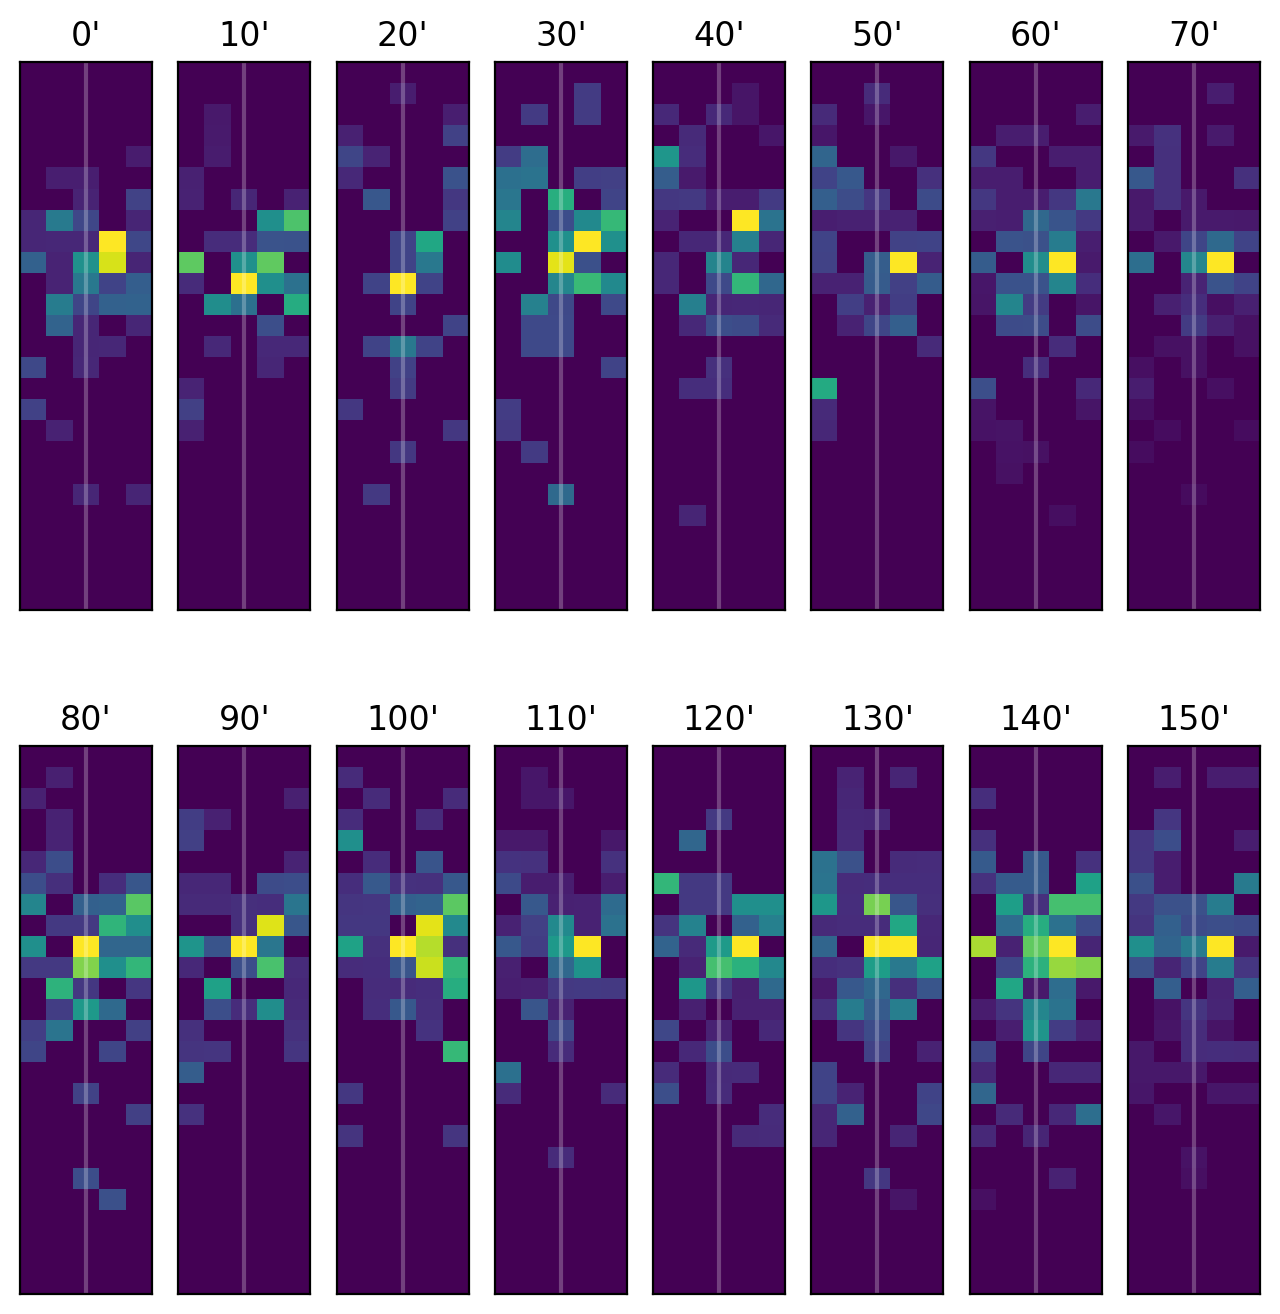

In [1269]:
plot_G_img_data(G1_img_data)

In [1260]:
smooth_transition_G1 = smooth_transition_G1.reshape((G1_img_data.shape[0], -1))
smooth_transition_G2 = smooth_transition_G2.reshape((G2_img_data.shape[0], -1))

In [1202]:
genome_deconvolution.combined_model.deconvolve(gamma=0.0066, G1=smooth_transition_G1,
                                              G2=smooth_transition_G2)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 130)
Deconvolving with gamma=0.0066
0/130 - 00:00:00.112
Deconvolved in : 00:00:13.927
The fitting norm is 0.54, the smoothing norm is: 13.50


In [1203]:
f = genome_deconvolution.combined_model.deconvolved_f_value.copy()

In [1204]:
f_imgs = f.reshape((178, 26, -1))

Text(0.5, 1.0, 'Example cell curve')

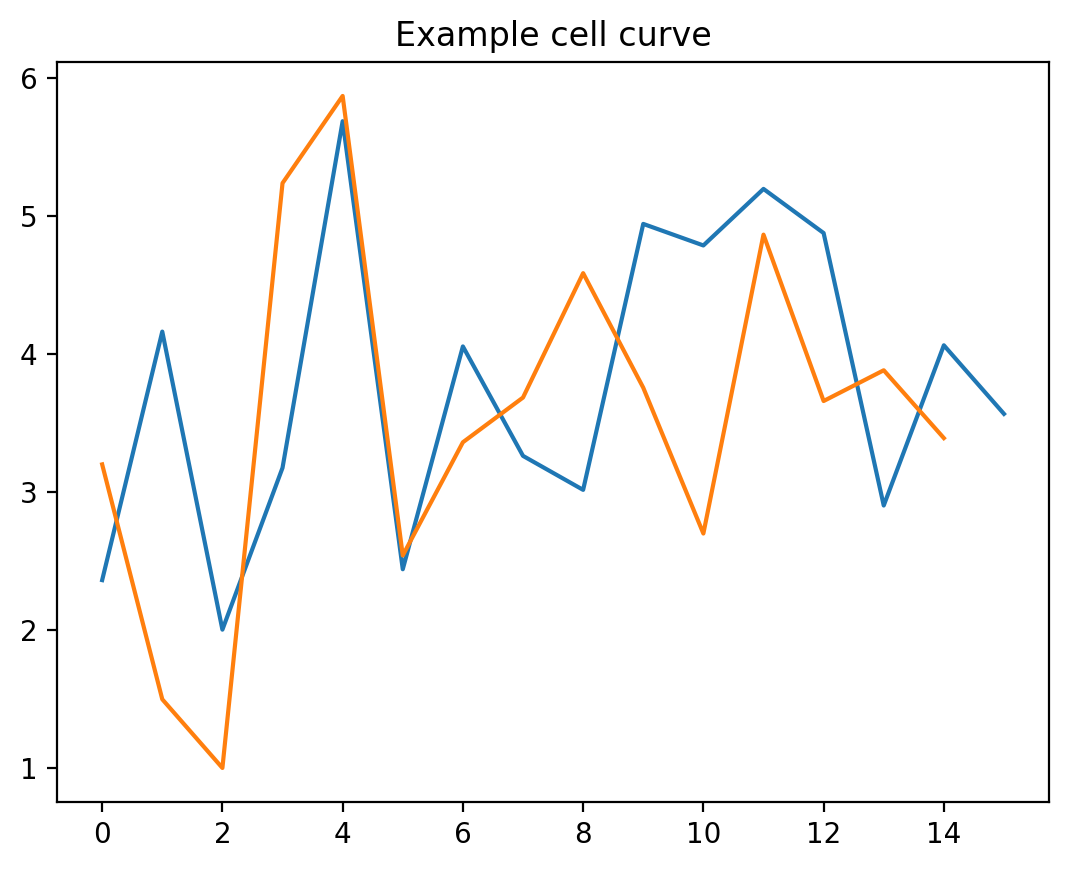

In [1271]:
plt.plot(G1_img_data.reshape((16, -1))[:, 78])
plt.plot(G2_img_data.reshape((15, -1))[:, 78])
plt.title("Example cell curve")

(60.0, 110.0)

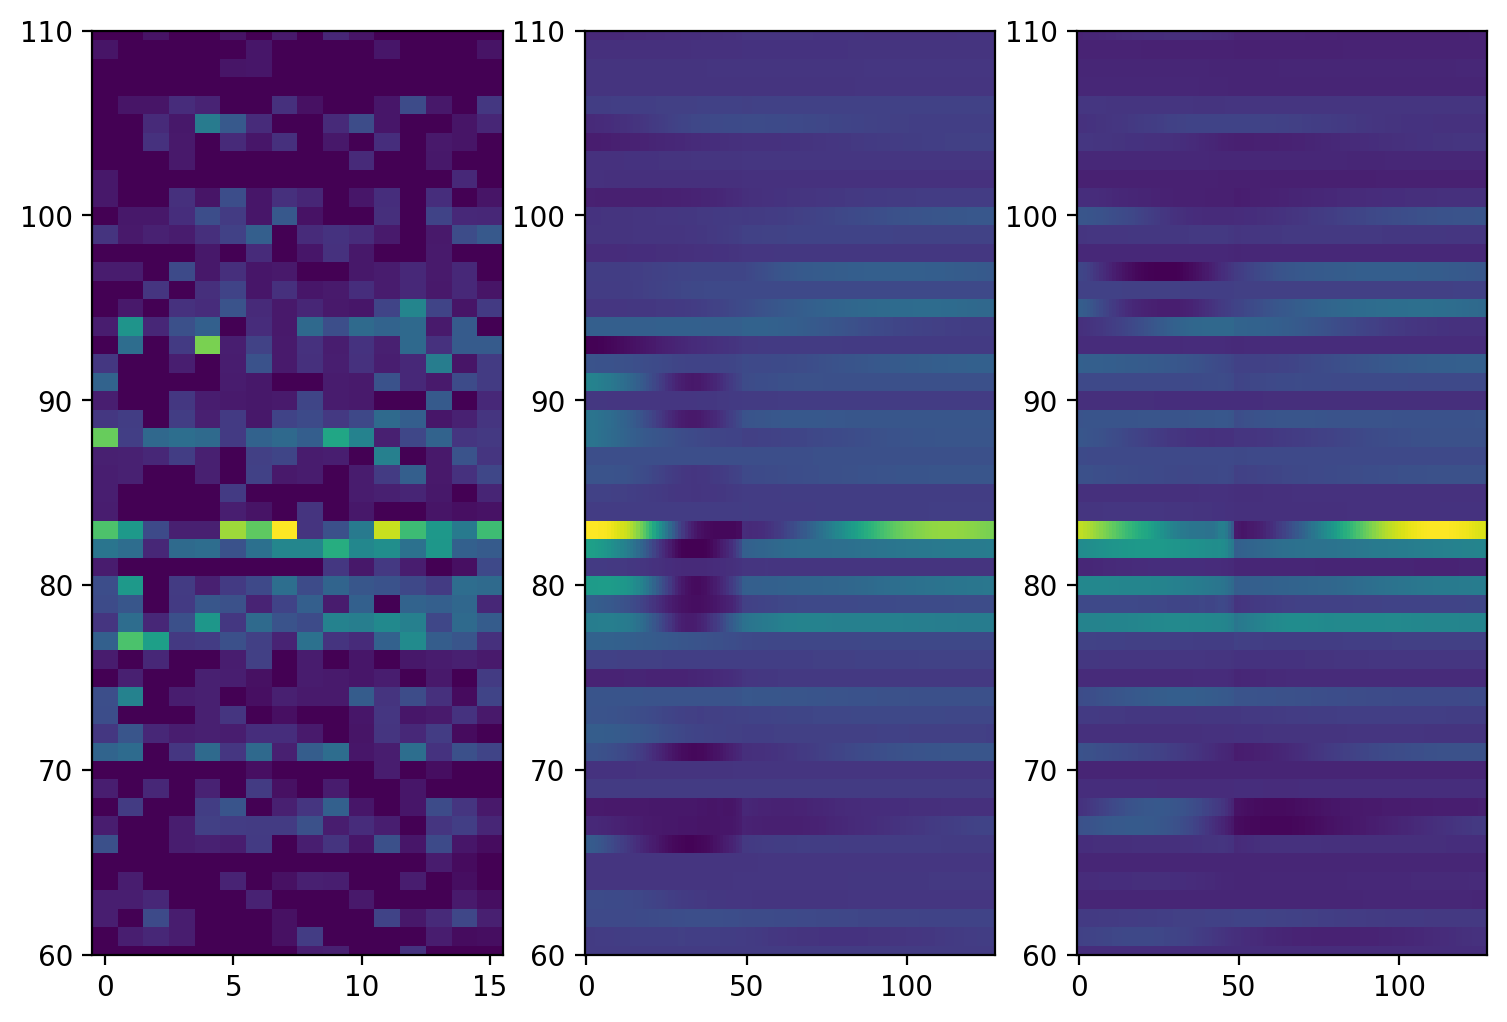

In [1208]:
plt.figure(figsize=(9, 6))

plt.subplot(1, 3, 1)
plt.imshow(G1_img_data.reshape((G1_img_data.shape[0], -1)).T, aspect='auto')
plt.ylim(60, 110)

plt.subplot(1, 3, 2)
plt.imshow(f[i_indices].T, interpolation='none', aspect='auto')
plt.ylim(60, 110)

plt.subplot(1, 3, 3)
plt.imshow(f[t_indices].T, interpolation='none', aspect='auto')
plt.ylim(60, 110)

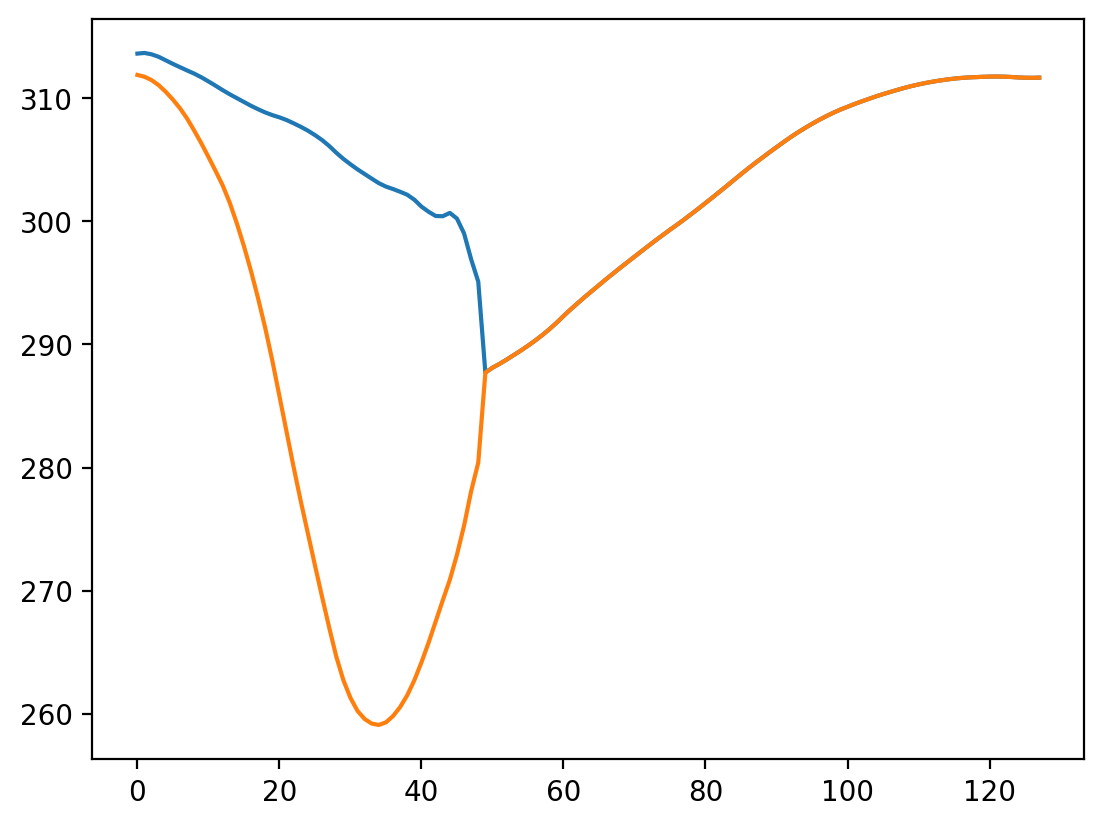

In [1213]:
plt.plot(f[t_indices].sum(axis=1))
plt.plot(f[i_indices].sum(axis=1))

In [1053]:
combined_model = genome_deconvolution.combined_model
combined_model.deconvolve(G1=selected_G1, G2=selected_G2, gamma=0.0066)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 1)
Deconvolving with gamma=0.0066
0/1 - 00:00:00.103
Deconvolved in : 00:00:01.247
The fitting norm is 0.22, the smoothing norm is: 7.85


November 19, 2024
--------------------------

## The goal
Identify very clearly the issue/bug with the model specifity that favors placing reads into CG1 over G2M and RG1. Here we will attempt to understand the root of the bug/problem.


### Ongoing working hypothesis
The expectation is that if there are two cells and the nucleosome is moving between them, the total sample count should sum to the same amount. 

However, because of the model specificity, there is a bias that would place read counts into G1. The CG1/RG1 buckets counter one another in order to achieve a proper and smooth fit. And G2/M appears to remain fixed, thus there is a bias towards placing reads into CG1 (RG1 is typically the negative anti-corollary bucket as it accounts for earlier read counts when there is a lower amount of reads).


In [1054]:
chrom1_model = genome_deconvolution.combined_model.chrom1_model

deconv_hist_reads = genome_deconvolution.combined_model.chrom1_model.deconv_hist_unflattened.copy()

example_simple_hist = (deconv_hist_reads[:, 14:15, 1:3] > 1) * 10
example_simple_hist.shape

(16, 1, 2)

In [1277]:
def plot_example(G1, G2, G3, gamma=0.0066):
    
    Gs = [G1, G2, G3]
    fig = plt.figure(figsize=(8, 7))
        
    for i in range(3):
        G = Gs[i]
        chrom1_model.G = G
        chrom1_model.gamma = gamma
        chrom1_model.deconvolve()
        tps = GlobalConstants.CHROM_WT1_TIMEPOINTS

        plt.subplot(3, 2, i*2+1)
        plt.plot(tps, chrom1_model.G)
        plt.title("Raw data")

        plt.subplot(3, 2, i*2+2)
        plt.plot(chrom1_model.deconvolved_f_value[t_indices, 0], label="Top")
        plt.plot(chrom1_model.deconvolved_f_value[i_indices, 0], label="Initial")
        plt.title("Deconvolved f")
        plt.legend()
        
    plt.subplots_adjust(hspace=0.5)

In [1056]:
G_S = chrom1_model.deconv_model.H[:, config.get_Hpositions_for_phase('S')].sum(axis=1)\
    .reshape((-1, 1))
G_S_offset1 = np.concatenate([G_S[1:2], G_S[1:]])
G_S_offset2 = np.concatenate([G_S[1:], G_S[-1:]])

In [1057]:
from src.helpers import smooth_transitions_custom

G1 = np.array([
        [1],
        [1],
        [1],
        [10],
        [10],
        [1],
        [1],
        [1],
        [1],
        [1],
        [10],
        [10],
        [1],
        [1],
        [1],
        [1],
])

G2 = smooth_transitions_custom(G1.flatten()).reshape(G1.shape)
G3 = smooth_transitions_custom(G1.flatten(), sigma=1, power=1).reshape(G1.shape)

rolled_G1 = np.roll(G1, 1, axis=0)
rolled_G2 = np.roll(G2, 1, axis=0)
rolled_G3 = np.roll(G3, 1, axis=0)

rolled_G1_rev = np.roll(G1, -1, axis=0)
rolled_G2_rev = np.roll(G2, -1, axis=0)
rolled_G3_rev = np.roll(G3, -1, axis=0)


Deconvolving with gamma=0.007
0/1 - 00:00:00.093
Deconvolved in : 00:00:00.822
The fitting norm is 3.21, the smoothing norm is: 3.88
Deconvolving with gamma=0.007
0/1 - 00:00:00.101
Deconvolved in : 00:00:00.835
The fitting norm is 3.09, the smoothing norm is: 47.27
Deconvolving with gamma=0.007
0/1 - 00:00:00.101
Deconvolved in : 00:00:00.818
The fitting norm is 4.30, the smoothing norm is: 55.53


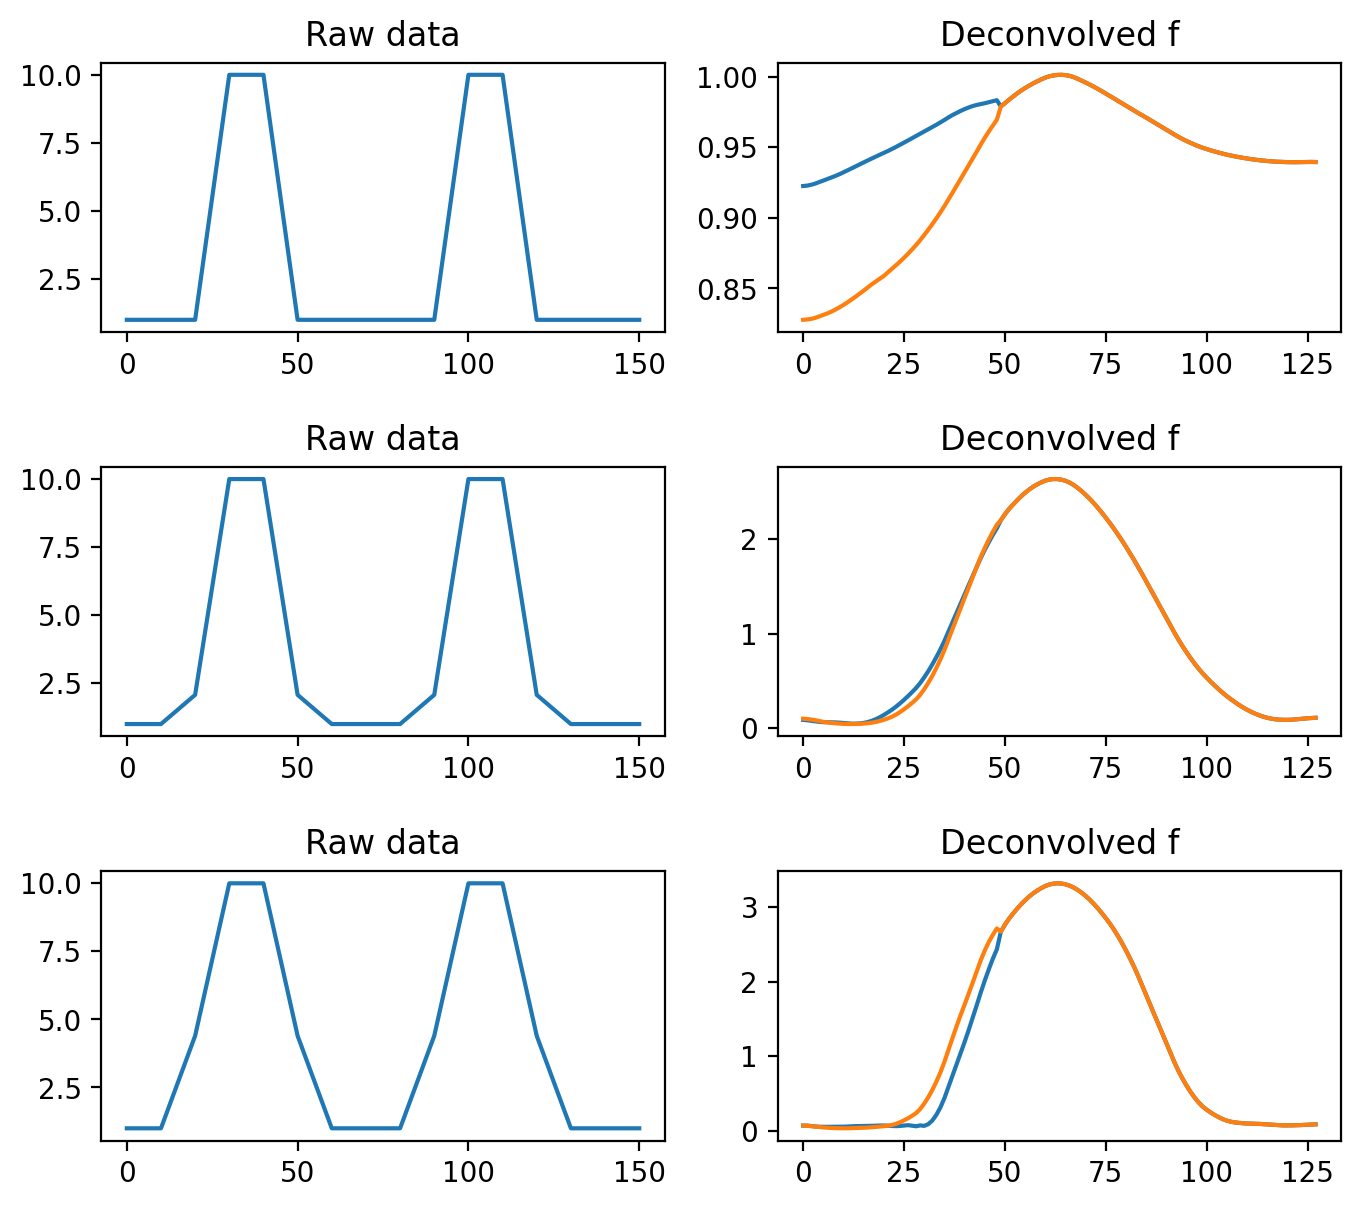

In [1058]:
plot_example(G1, G2, G3, gamma=0.007)

Deconvolving with gamma=0.007
0/1 - 00:00:00.092
Deconvolved in : 00:00:00.788
The fitting norm is 3.21, the smoothing norm is: 4.43
Deconvolving with gamma=0.007
0/1 - 00:00:00.098
Deconvolved in : 00:00:00.816
The fitting norm is 3.17, the smoothing norm is: 42.83
Deconvolving with gamma=0.007
0/1 - 00:00:00.102
Deconvolved in : 00:00:00.828
The fitting norm is 4.35, the smoothing norm is: 57.94


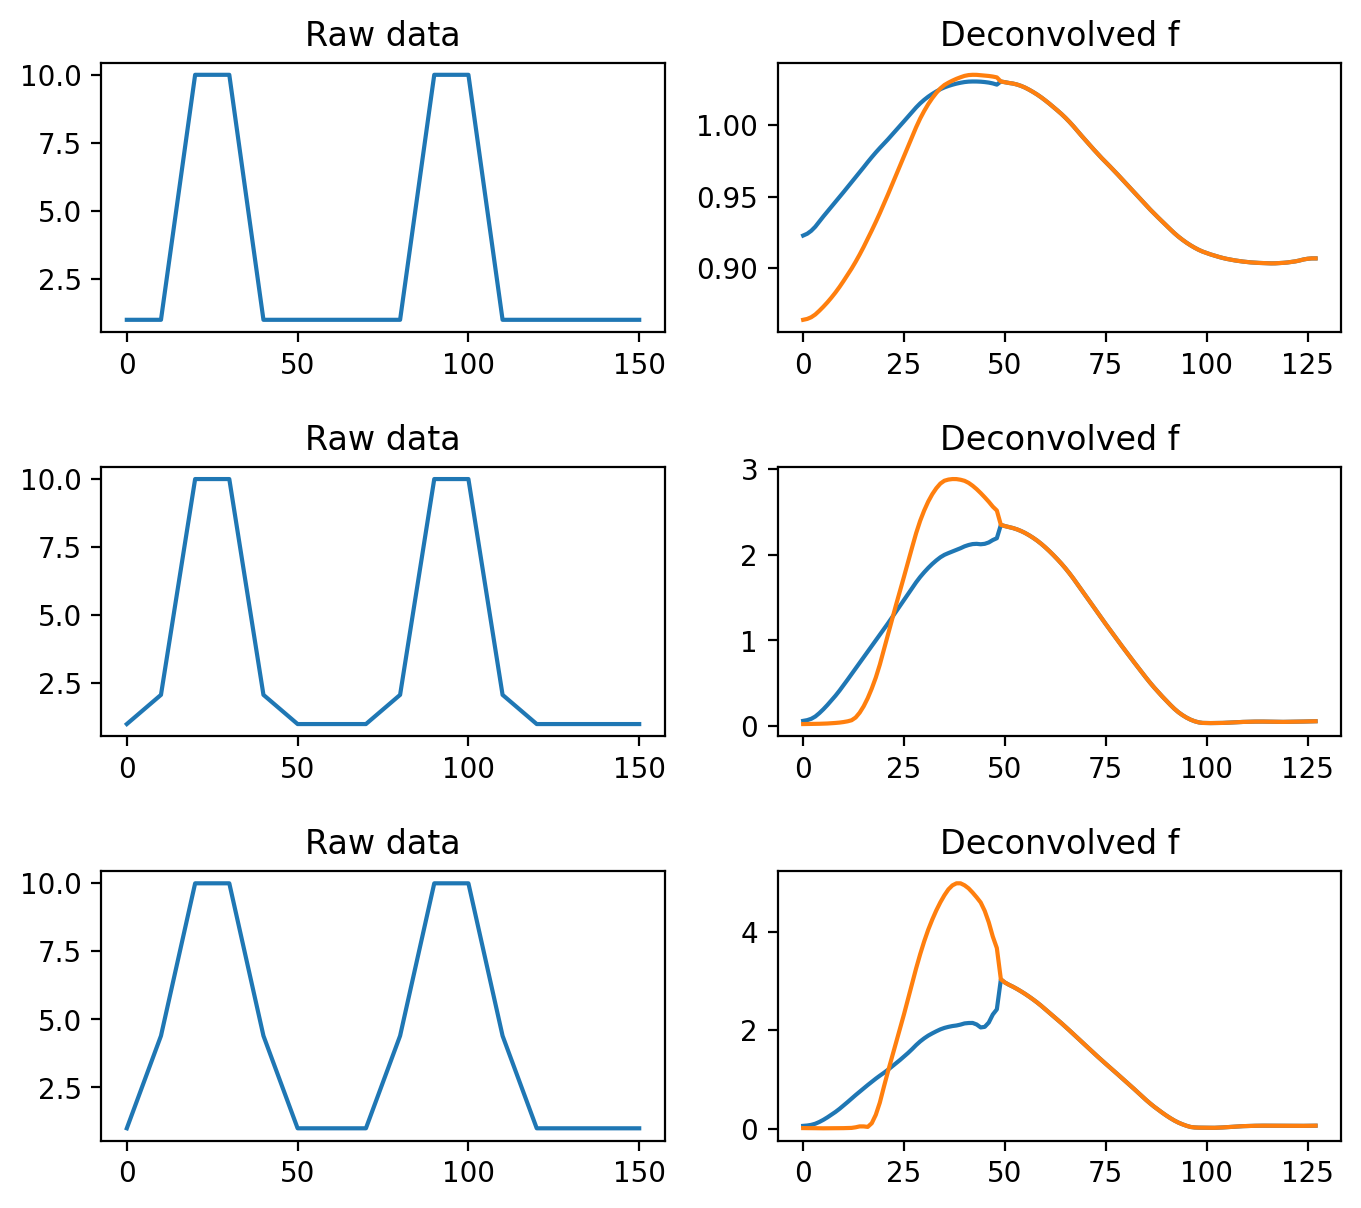

In [1059]:
plot_example(rolled_G1_rev, rolled_G2_rev, rolled_G3_rev, gamma=0.007)

Deconvolving with gamma=0.007
0/1 - 00:00:00.092
Deconvolved in : 00:00:00.792
The fitting norm is 3.21, the smoothing norm is: 4.29
Deconvolving with gamma=0.007
0/1 - 00:00:00.097
Deconvolved in : 00:00:00.825
The fitting norm is 3.06, the smoothing norm is: 41.05
Deconvolving with gamma=0.007
0/1 - 00:00:00.099
Deconvolved in : 00:00:00.849
The fitting norm is 4.30, the smoothing norm is: 47.77


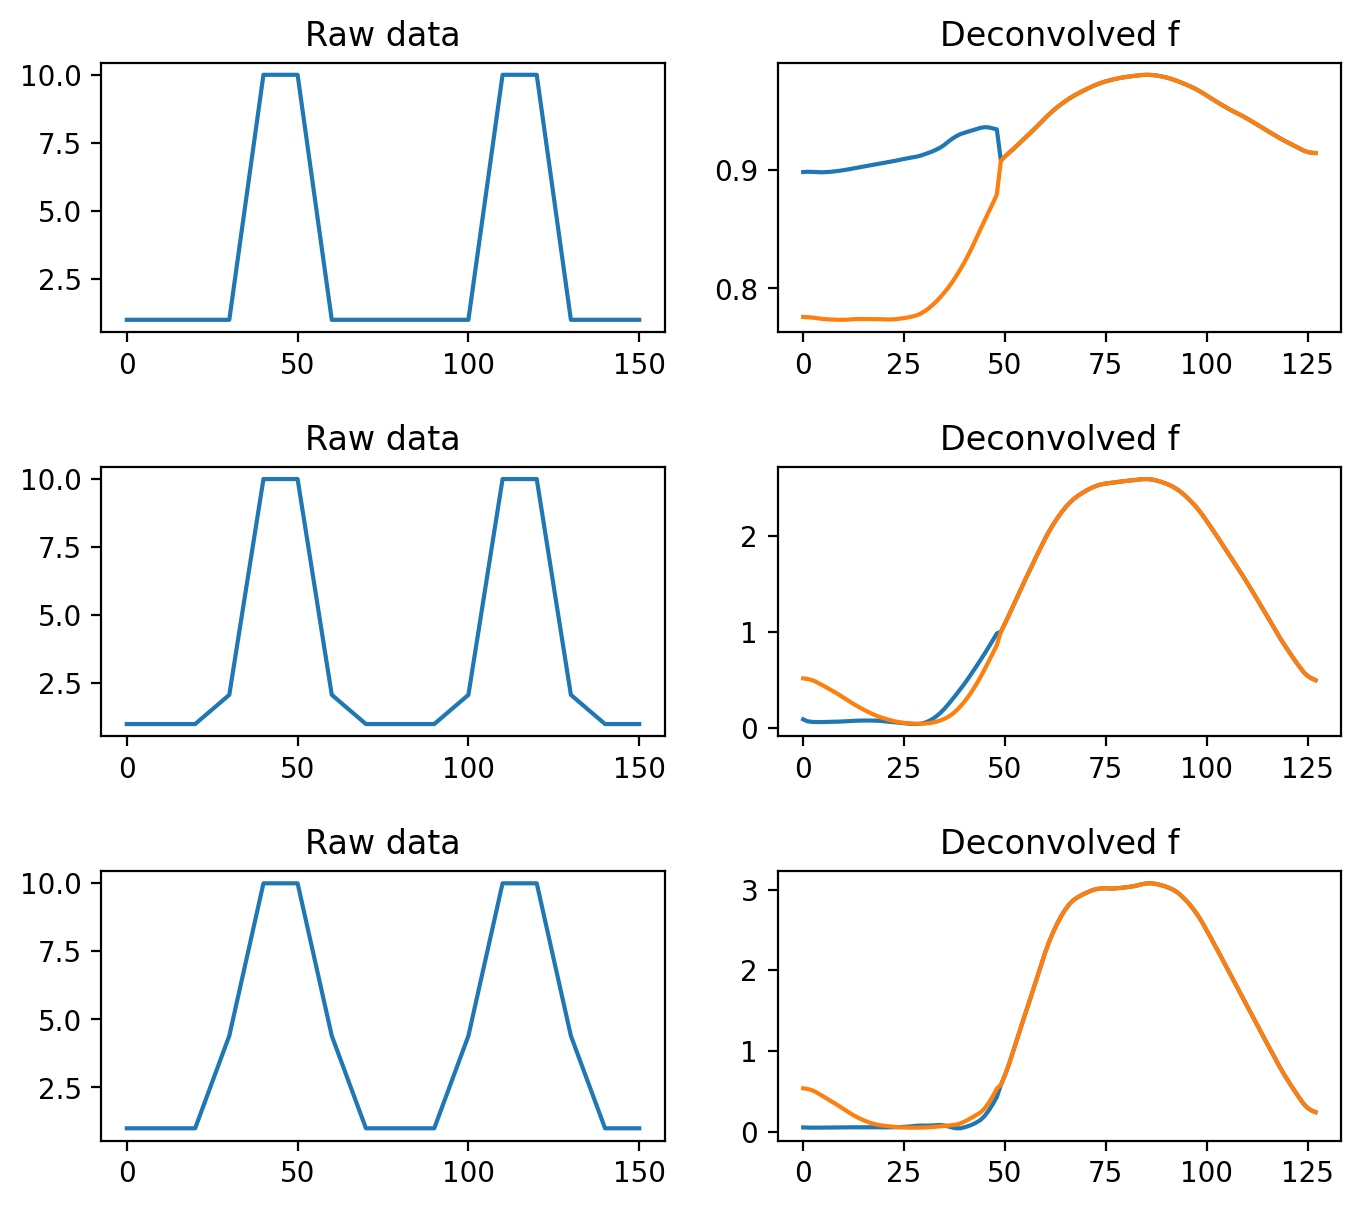

In [1060]:
plot_example(rolled_G1, rolled_G2, rolled_G3, gamma=0.007)

In [1275]:
# Examination of real data now:

G1_sample_vector = G1_img_data.reshape((16, -1))[:, 78]
G2_sample_vector = G2_img_data.reshape((15, -1))[:, 78]

smoothed_G1 = smooth_transitions_custom(G1_sample_vector)
smoothed_G2 = smooth_transitions_custom(G2_sample_vector)

# Didn't quite smooth the sharp transitions as expected, although it may not be possible 
# with the zig-zagginess of this datapoint.....
chrom1_model.G = smoothed_G1.reshape((-1, 1))
chrom1_model.gamma = 0.0066
chrom1_model.deconvolve()

Deconvolving with gamma=0.0066
0/1 - 00:00:00.143
Deconvolved in : 00:00:00.870
The fitting norm is 0.92, the smoothing norm is: 19.37


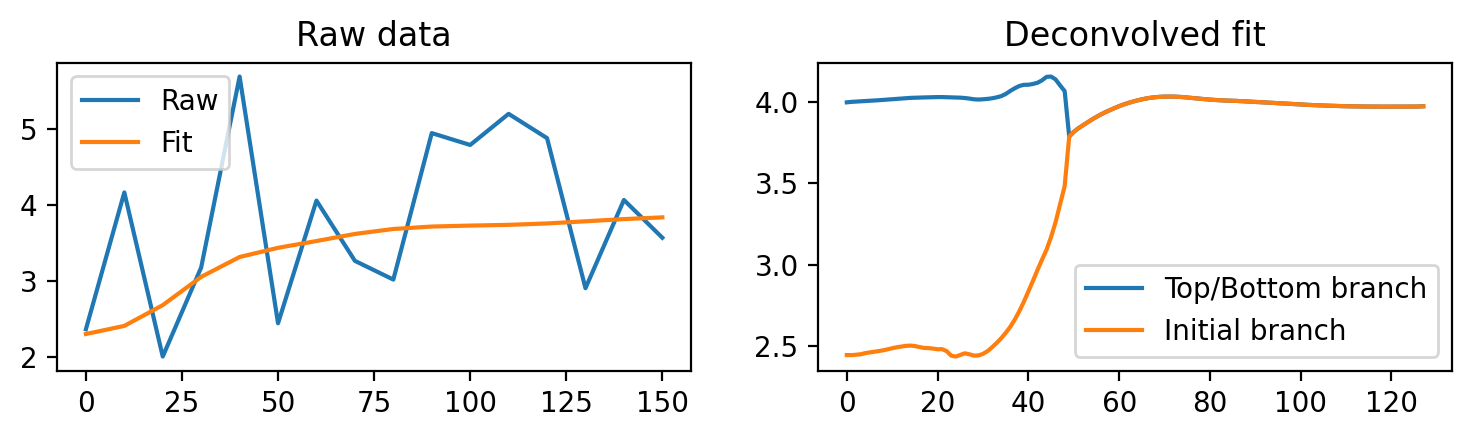

In [1281]:
f = chrom1_model.deconvolved_f_value

plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(tps, G1_sample_vector, label="Raw")
plt.plot(tps, chrom1_model.deconv_model.H @ f, label='Fit')
plt.title("Raw data")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(f[t_indices], label="Top/Bottom branch")
plt.plot(f[i_indices], label='Initial branch')
plt.title("Deconvolved fit")
plt.legend()

# When the model attempts the default curve, of low occupancy in the initial branch
# and more occupancy in the top and bottom branch

# In this case, I would prefer if this model fit a curve that matched the larger peaks
# and showed cycling rather than a smooth transition. There is too much noise....


In [1189]:
# Does the model have issue with low occupancy in recovery and higher occupancy in the 
# cell cycle phase? the first S/G2M appears to desire to fit to the same level causing the
# model to use RG1 and CG1 to try and fit the data.....

test_G = np.array([1.15748558, 1.43664809, 1.89099618, 2.3350607 , 
    2.58219142, 2.68935178, 2.78499573, 2.88643794, 2.95522993, 
    2.98991333, 3.00733831, 3.02376952, 3.04959749, 3.0831465 ,
    3.11511314, 3.13998858])

chrom1_model.G = test_G.reshape((-1, 1))
chrom1_model.gamma = 0.0#01
chrom1_model.deconvolve()

Deconvolving with gamma=0.0
0/1 - 00:00:00.076
Deconvolved in : 00:00:00.792
The fitting norm is 0.00, the smoothing norm is: 123.78


Text(0.5, 1.0, 'Deconvolved fit')

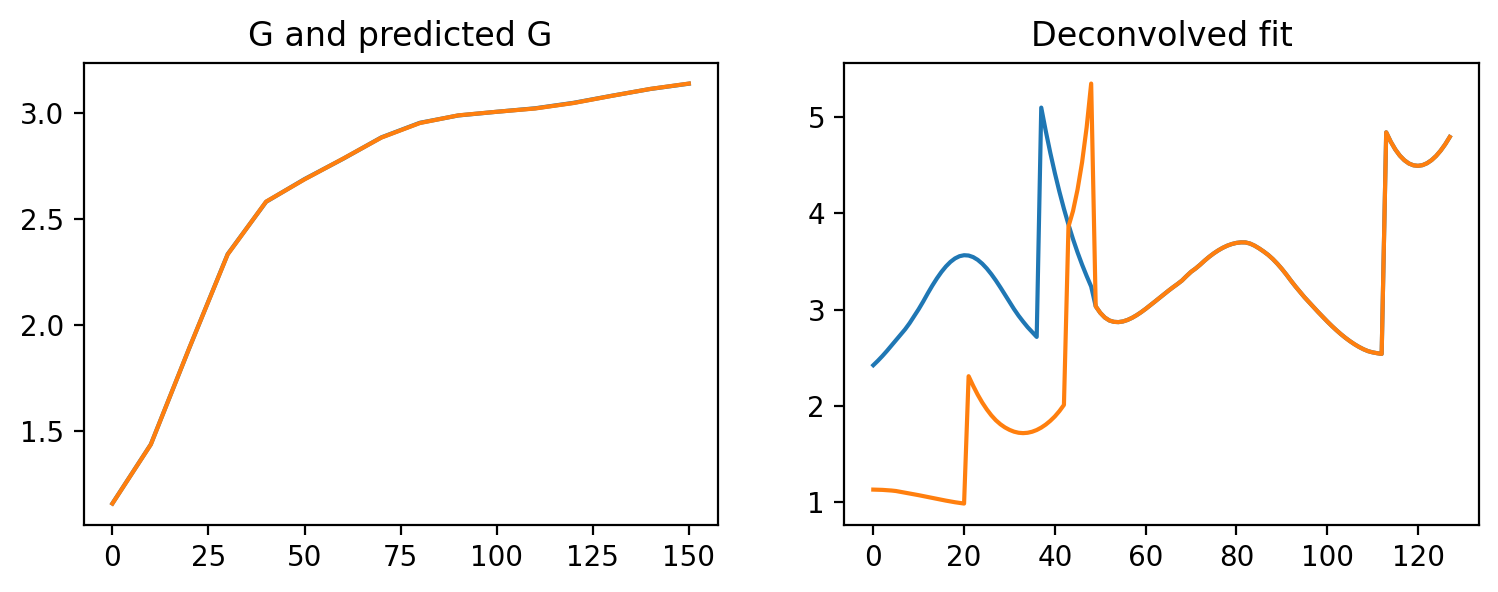

In [1190]:
f = chrom1_model.deconvolved_f_value

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(tps, test_G)
plt.plot(tps, chrom1_model.deconv_model.H @ f)
plt.title("G and predicted G")

plt.subplot(1, 2, 2)
plt.plot(f[t_indices])
plt.plot(f[i_indices])
plt.title("Deconvolved fit")

In [1188]:
# Modeling issue, why is the model not fitting the exact values I gave to in the prediction?
# is the smoothing outcompeting the fit here?

# Its seems like this model needs to be fit with a Recovery S and G2M
# Is it possible to allow for a recovery S and G2M that values with the top and bottom
# branch S and G2M values? Potentially through a scaling factor/weighting scheme?
# This is a modeling question that needs to be resolved with Alex.

# We may just need to add the recovery S-phase: RS...


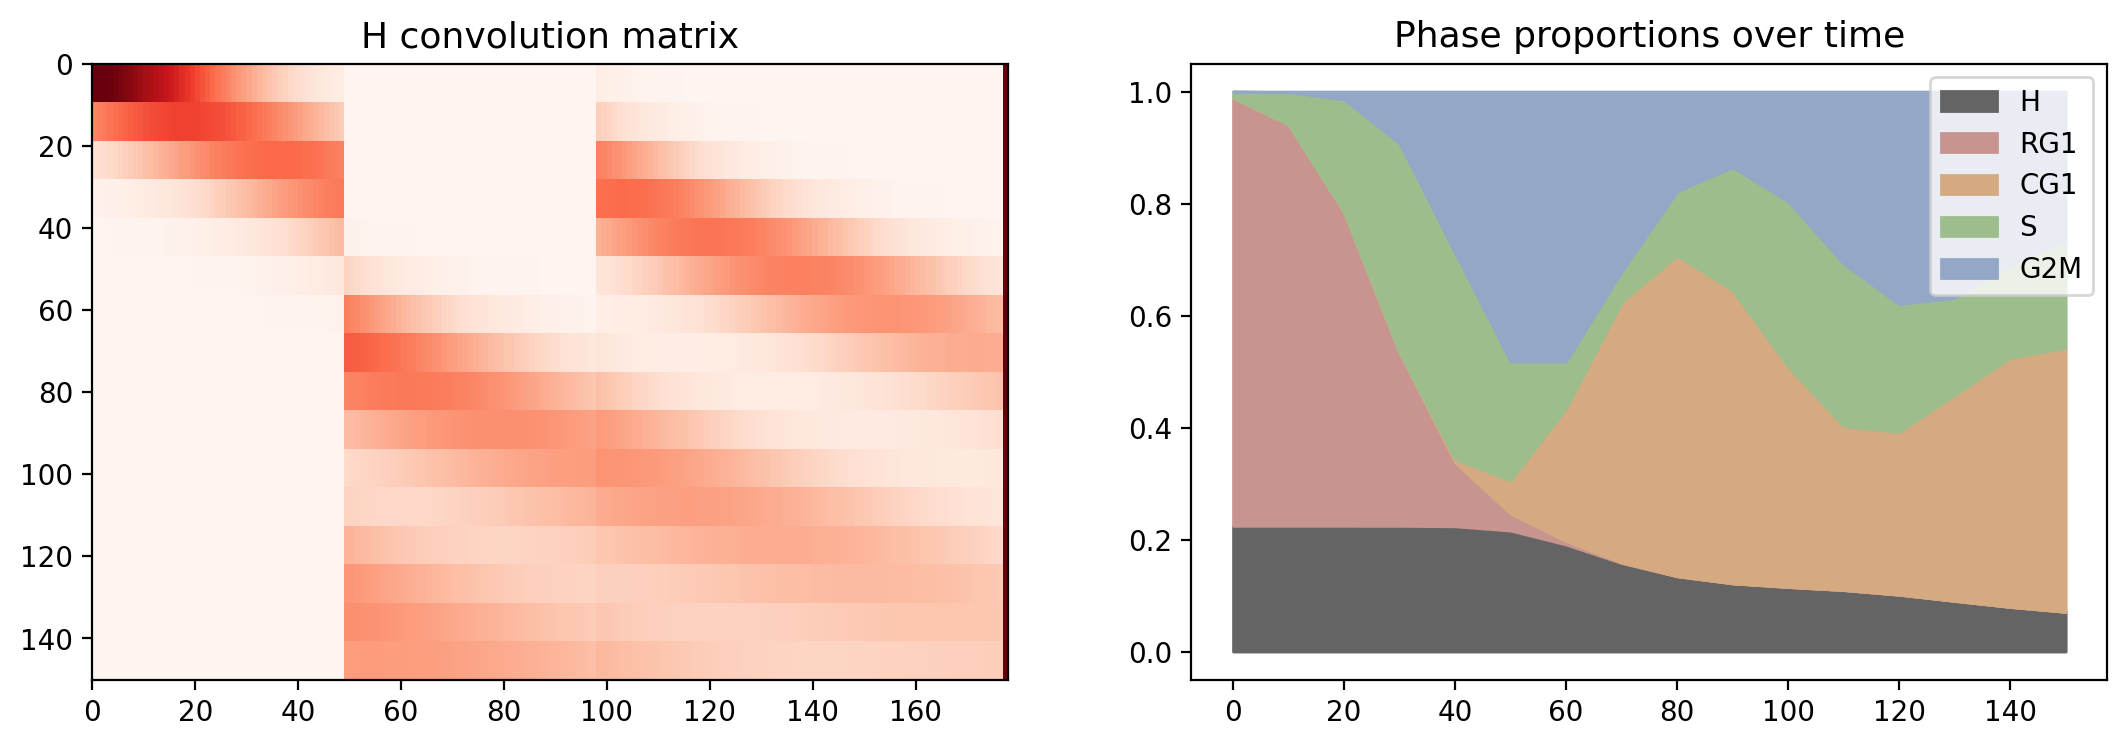

In [1193]:
# I think we have the problem understood to enouugh of an extent.....
plot_H(chrom1_model.config, chrom1_model.deconv_model.H)